# How Does Reward Change the Model?
## Reward tells us which outputs are preferred; reinforcement learning changes the policy so higher-reward outputs become more likely.

#  Part 3 — Using Rewards to Change the Policy

In Part 2, we built this:

                    Prompt
                       ↓
                      LLM
                       ↓
                    Response
                       ↓
                    Reward Model
                       ↓
                    Reward

But we ended with a question:

> **What do we actually DO with the reward?**

Suppose:

Response A → Reward = 0.2  
Response B → Reward = 0.9

We want the model to learn:

> "Responses like B should become more likely."

This is where **Reinforcement Learning** enters the RLHF pipeline.

In [ ]:
#  Remember: What Is a Policy?

A policy is the agent's strategy for choosing actions.

In our door experiment:
                A → 10%  
                B → 20%  
                C → 70%

For a language model, we can think of the policy as:

> **The probability distribution the model uses to generate outputs.**

For example:
        Prompt:
            "Explain gravity to a child."

Possible responses:

            Simple explanation      → 20%
            Technical explanation   → 50%
            Irrelevant explanation  → 30%

These probabilities represent our simplified **LLM policy**.

## In RLHF, the LLM itself is the policy we are trying to improve.

In [2]:
# building a small language model

responses = [
    "Simple helpful explanation",
    "Very technical explanation",
    "Irrelevant response"
]

policy = {
    responses[0]: 0.20,
    responses[1]: 0.50,
    responses[2]: 0.30
}

print("Current LLM Policy:\n")

for response, probability in policy.items():
    print(f"{response:30} → {probability:.0%}")

Current LLM Policy:

Simple helpful explanation     → 20%
Very technical explanation     → 50%
Irrelevant response            → 30%


In [5]:
# Run this again & again & .......

import random

def generate_response(policy):
    return random.choices(
        list(policy.keys()),
        weights=list(policy.values())
    )[0]


for i in range(10):
    response = generate_response(policy)
    print(f"{i+1:2}. {response}")

 1. Very technical explanation
 2. Very technical explanation
 3. Irrelevant response
 4. Very technical explanation
 5. Irrelevant response
 6. Very technical explanation
 7. Very technical explanation
 8. Very technical explanation
 9. Very technical explanation
10. Simple helpful explanation


### This model isn't necessarily "bad." Its current policy simply gives the technical response the highest probability.

# The Reward Model Evaluates Responses

Imagine our Reward Model learned the following preferences:

Simple helpful explanation
        → Reward = 1.0

Very technical explanation
        → Reward = 0.3

Irrelevant response
        → Reward = 0.0

So the response humans prefer receives the largest reward.

In [7]:
# We would need to get some rewards like this so implementing the same, inroder to update the model  

rewards = {
    "Simple helpful explanation": 1.0,
    "Very technical explanation": 0.3,
    "Irrelevant response": 0.0
}

for response, reward in rewards.items():
    print(f"{response:30} → Reward = {reward}")

Simple helpful explanation     → Reward = 1.0
Very technical explanation     → Reward = 0.3
Irrelevant response            → Reward = 0.0


## Our model currently generates the technical response most often, but the reward model prefers the simple response. What should learning do... we need to increase the probability of simple response

#  Reinforcement Learning

-------------------------->>>>>>>The idea is surprisingly simple:

### Generate an action

            ↓

### Observe its reward

            ↓

### If the reward is high

Make that action **more likely**

            ↓

### If the reward is low

Make that action **less attractive relative to better actions**

            ↓

### Repeat


Over many updates, the policy shifts toward actions
that receive higher reward.

#### Real policy-gradient updates are not simply “positive reward means increase, negative reward means decrease.” They usually use relative performance, such as an advantage estimate.

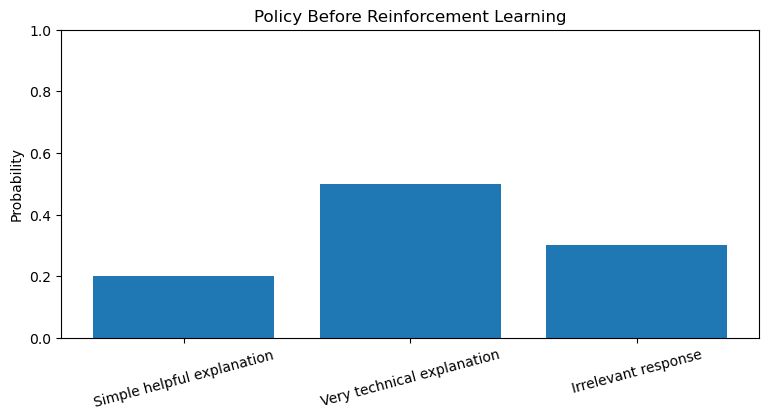

In [8]:
# Before training 

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))

plt.bar(
    list(policy.keys()),
    list(policy.values())
)

plt.ylabel("Probability")
plt.title("Policy Before Reinforcement Learning")
plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

In [ ]:
# Lets say there is a policy update

In [9]:
learning_rate = 0.1

def update_policy(policy, chosen_response, reward):

    # Increase the weight of the chosen response
    policy[chosen_response] += learning_rate * reward

    # Normalize so probabilities sum to 1
    total = sum(policy.values())

    for response in policy:
        policy[response] /= total

    return policy

In [10]:
policy = {
    "Simple helpful explanation": 0.20,
    "Very technical explanation": 0.50,
    "Irrelevant response": 0.30
}

history = []

for step in range(200):

    # 1. Generate response
    response = generate_response(policy)

    # 2. Get reward
    reward = rewards[response]

    # 3. Update policy
    policy = update_policy(
        policy,
        response,
        reward
    )

    history.append(policy.copy())

In [11]:
print("Policy after training:\n")

for response, probability in policy.items():
    print(f"{response:30} → {probability:.2%}")

Policy after training:

Simple helpful explanation     → 100.00%
Very technical explanation     → 0.00%
Irrelevant response            → 0.00%


In [12]:
before = {
    "Simple helpful explanation": 0.20,
    "Very technical explanation": 0.50,
    "Irrelevant response": 0.30
}

print("BEFORE RL")
print("-" * 40)

for response, probability in before.items():
    print(f"{response:30} {probability:.0%}")

print("\nAFTER RL")
print("-" * 40)

for response, probability in policy.items():
    print(f"{response:30} {probability:.0%}")

BEFORE RL
----------------------------------------
Simple helpful explanation     20%
Very technical explanation     50%
Irrelevant response            30%

AFTER RL
----------------------------------------
Simple helpful explanation     100%
Very technical explanation     0%
Irrelevant response            0%


In [ ]:
"Did we change the reward model?"
        No.

"What did we change?"
The policy.

And in RLHF:
        The LLM is the policy.!!!!!!

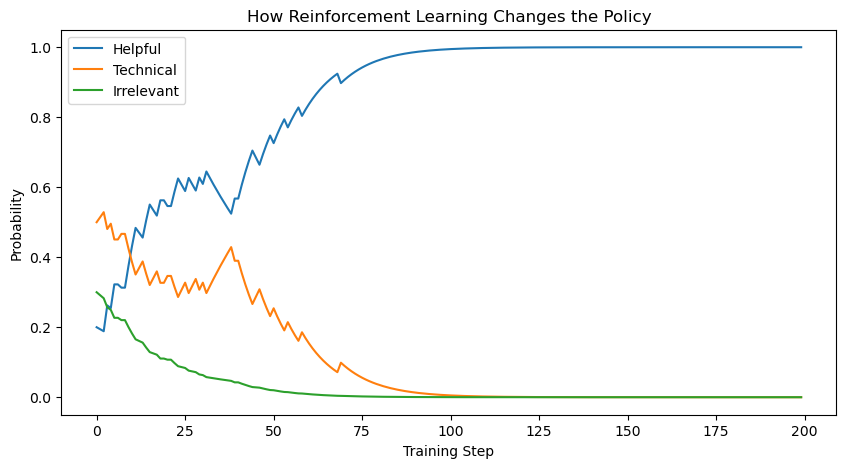

In [13]:
helpful_history = [
    h["Simple helpful explanation"]
    for h in history
]

technical_history = [
    h["Very technical explanation"]
    for h in history
]

irrelevant_history = [
    h["Irrelevant response"]
    for h in history
]

plt.figure(figsize=(10, 5))

plt.plot(helpful_history, label="Helpful")
plt.plot(technical_history, label="Technical")
plt.plot(irrelevant_history, label="Irrelevant")

plt.xlabel("Training Step")
plt.ylabel("Probability")
plt.title("How Reinforcement Learning Changes the Policy")

plt.legend()

plt.show()

### RL is not storing "Response B is good." It is changing the model's behaviour so responses receiving higher reward become more probable.

#  What Changes Inside a Real LLM?

Our tiny model stored probabilities directly:

Helpful → 20%

Technical → 50%

Irrelevant → 30%

A real LLM does not store a table like this.

Instead, it contains billions of learned parameters:

θ₁, θ₂, θ₃, ... θₙ

These parameters determine the probabilities of tokens.

For example:

"The sky is..."

blue     → 72%

green    → 4%

falling  → 2%

...

Reinforcement learning updates the model parameters.

Changing the parameters changes token probabilities.

Changing token probabilities changes the responses
the model is likely to generate.

# LLM as a Policy

In Reinforcement Learning, we often write a policy as:

π(a | s)

Meaning:

> Probability of taking action **a**
> given state **s**

For an LLM we can think of:

State → Prompt + tokens generated so far

Action → Next token

Policy → LLM

So:

π(token | prompt, previous tokens)

represents the probability that the LLM generates
a particular next token.

#### Our language model with parameters θ, viewed as a policy.

#  Traditional RL vs RLHF

| Reinforcement Learning | LLM / RLHF |
|---|---|
| Agent | LLM |
| State | Prompt + generated context |
| Action | Generated token / response |
| Policy | LLM's probability distribution |
| Reward | Reward Model score |
| Policy Update | Update LLM parameters |

The fundamental objective remains:

> **Increase expected reward by improving the policy.**

# What Happens If We Just Maximize Reward?

### Do you think something could go wrong here !? ! ?

Our objective currently says:

> "Get as much reward as possible."

But think about this carefully.

If the Reward Model is imperfect...

Could the LLM discover strange ways of getting
a very high reward?

Could it exploit weaknesses in the Reward Model?

Could the model change too much?

Could language quality deteriorate?

Could it learn behavior that scores well without actually
being what humans intended?

This problem is related to:

## Reward Hacking / Overoptimization

# THINK !

Suppose our Reward Model accidentally learns:

"Longer answers are better."

Then the model discovers:

Long answer → Higher reward

So it starts producing:

VERY...
VERY...
VERY...
VERY...
VERY...

long answers.

The Reward Model says:

            Excellent! Reward = 10!

But humans say:

            "This isn't what we wanted."

---

The model optimized the reward...

but not the true human intention.

#  Don't Let the Model Drift Too Far

Before reinforcement learning, we already had a reasonably
good language model.

Usually, it has gone through:

1. Pretraining
2. Supervised Fine-Tuning (SFT)

We don't want reinforcement learning to completely destroy
that behaviour.

So we keep a copy of the model before RL.

This is called the:

# Reference Model

In [ ]:
                SFT Model
                   │
             ┌─────┴─────┐
             │           │
             ▼           ▼
         RL Policy    Reference
          Model         Model
             │           │
             └─────┬─────┘
                   │
                 Compare

# How Far Did the Policy Move?

Suppose the original model says:

    Helpful     → 40%
    Technical   → 40%
    Irrelevant  → 20%

After RL:

    Helpful     → 99.9%
    Technical   → 0.09%
    Irrelevant  → 0.01%

The policy has changed dramatically.

We need a way to measure:

                > "How different is the new policy from the original model?"

One common measure is # KL Divergence

#   Our Objective Is No Longer Just...

Maximize:
            Reward

Instead, we want something like:

## Maximize
            Reward − β × KL Penalty

Where:

**Reward**
            → Move toward responses humans prefer
            
**KL Penalty**
            → Don't move too far from the reference model
            
**β**
            → Controls the trade-off

## so it is like something like this - Improve according to human feedback, but don't forget how to be a language model.

In [17]:
reward = 0.9
kl_penalty = 0.2
beta = 0.1

objective = reward - beta * kl_penalty

print("Reward:", reward)
print("KL divergence:", kl_penalty)
print("Beta:", beta)

print("\nFinal RL objective:", objective)

Reward: 0.9
KL divergence: 0.2
Beta: 0.1

Final RL objective: 0.88


In [18]:
# look how i had changed the KL penalty

reward = 0.9
kl_penalty = 5.0
beta = 0.1

objective = reward - beta * kl_penalty

print("Final RL objective:", objective)

Final RL objective: 0.4


### Policy Gradient 

## Relative Reward Matters

## Our earlier simplified update had a flaw.
##     It treated every positive reward as something to reinforce.

 But imagine:

 Response A → reward 0.90
 Response B → reward 0.20

Both are positive.

# Should both receive the same reinforcement?

## We need to know whether a result was better or worse than expected.

#  Was the Response Better Than Expected?

Suppose the average expected reward is:
        0.5

Our response receives:
        0.9

Then:
Advantage = Reward − Expected Reward

Advantage = 0.9 − 0.5

Advantage = +0.4

This response was:

## Better than expected.

But if:
        Reward = 0.2
        
Then:

    Advantage = 0.2 − 0.5
    
    Advantage = -0.3

This response was:

## Worse than expected.

In [ ]:
# Policy Gradient Intuition

If:
    Advantage > 0

Increase the probability of the actions that produced the response.

If:
    Advantage < 0

Decrease their probability.

So the model gradually learns:

                    > "What kinds of generations produce better-than-expected rewards?"

#  PPO — Proximal Policy Optimization

Classic RLHF systems commonly used an RL algorithm called:

## PPO

Proximal Policy Optimization

Its job is to update the policy using reward information while preventing excessively large updates.

Very roughly:

                    Generate responses
                          ↓
                    Calculate rewards
                          ↓
                    Estimate advantages
                          ↓
                    Update policy
                          ↓
                    Keep the update controlled
                          ↓
                        Repeat

## PPO is not RLHF itself. PPO is one possible reinforcement-learning algorithm used inside an RLHF pipeline.

#  Why Is It Called "Proximal"?

Imagine the policy changes:

Before update:
         Helpful → 30%

After ONE update:
        Helpful → 99.99%

          Thats an enormous jump! .

Large policy updates can make training unstable.

PPO tries to keep each update relatively conservative.

In simple terms:

        > **Learn — but don't change too much at once.**

# The Classic RLHF Optimization Loop

### 1. Give the LLM a prompt

                ↓

### 2. LLM generates a response

                ↓

### 3. Reward Model scores the response

                ↓

### 4. Compare with the Reference Model

                ↓

### 5. Calculate the training objective

Reward − KL penalty

                ↓

### 6. Estimate how good the generation was

Advantage

                ↓

### 7. PPO updates the LLM policy

                ↓

### 8. Repeat

In [ ]:
                       Prompt
                         │
                         ▼
                ┌────────────────┐
                │   LLM POLICY   │
                │      πθ        │
                └───────┬────────┘
                        │
                     Response
                        │
             ┌──────────┴──────────┐
             │                     │
             ▼                     ▼
      ┌──────────────┐      ┌──────────────┐
      │ Reward Model │      │  Reference   │
      │              │      │    Model     │
      └──────┬───────┘      └──────┬───────┘
             │                     │
           Reward               KL penalty
             │                     │
             └──────────┬──────────┘
                        │
                        ▼
                  RL Objective
                        │
                        ▼
                 Advantage / PPO
                        │
                        │
                        └────────────► Update πθ

#  Challenge

Suppose the LLM generates Response A.

Reward Model:

    Reward = 0.90

But the response is very different from what the
Reference Model would normally produce.

    KL penalty = 0.80

Now consider another response:

Response B

    Reward = 0.82
    KL penalty = 0.05


### Questions

1. Which response has the higher raw reward?
2. Why might we still prefer the update associated with B?
3. What is the purpose of the KL penalty?
4. What model is actually being updated?

In [ ]:
# Answers 
1. Response A has the higher raw reward.
2. B may provide a better trade-off between reward
   and staying close to the reference policy.
3. KL discourages the policy from drifting too far.
4. The LLM policy is being updated.

# RLHF Mapping

Human
  ↓
Preferences
  ↓
Reward Model
  ↓
Reward
  ↓
Reinforcement Learning
  ↓
Update LLM Policy

In [ ]:
#  What Have We Learned?

## Part 1 — Reinforcement Learning

Agent
    → Action
    → Reward
    → Update Policy


## Part 2 — Human Feedback

Humans compare responses
    → Preference Dataset
    → Train Reward Model
    → Produce Reward


## Part 3 — Policy Optimization

LLM generates response
    → Reward Model scores it
    → RL algorithm uses the reward
    → Update LLM parameters
    → Preferred behaviour becomes more likely

#  One Final Question...

Did we start with a completely random LLM and immediately apply RLHF?

    ## No.

Before RLHF, something else happened.

The model first learned language.

Then it learned to follow instructions.

Then humans expressed preferences.

Then reinforcement learning refined its behaviour.

So...

# How does an LLM go from raw text → Chat Assistant?

In [ ]:
???????????
     ↓
 Base LLM
     ↓
???????????
     ↓
 SFT Model
     ↓
Human Preferences
     ↓
Reward Model
     ↓
RL / PPO
     ↓
Post-trained LLM